In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image


In [2]:
class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

class ThinkingState(TypedDict):
    notes: str
    answer: str

class AnswerState(TypedDict):
    answer: str

In [3]:
def thinking_node(state: OverallState):
    return {"answer": "This is my answer", "notes": "This is my notes"}

def answer_node(state: OverallState):
    return {"answer": "This is my answer"}



In [8]:
graph = StateGraph(OverallState, input_schema=ThinkingState, output_schema=AnswerState)

graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node",thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)



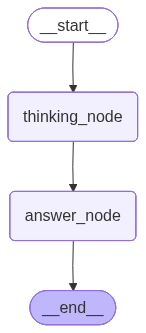

In [9]:
graph = graph.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
graph.invoke({"question":"hi"})

{'answer': 'This is my answer'}